# GLOBAL DEVELOPMENT MEASUREMENT PROJECT:

## 1. DATA LOADING

### 1.1 Import Required Libraries:

In [8]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

plt.style.use("seaborn-v0_8")


### 1.2 Load the Dataset:

In [9]:
df = pd.read_excel("D:\data science\Project\clustering\World_development_mesurement (1) (1).xlsx")
df.head()


,Birth Rate,Business Tax Rate,CO2 Emissions,Country,Days to Start Business,Ease of Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,...,Life Expectancy Male,Mobile Phone Usage,Number of Records,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound
0,0.020,NaN,87931.0,Algeria,NaN,NaN,26998.0,"$54,790,058,957",0.035,$60,...,67.0,0.0,1,0.342,0.619,0.039,31719449,0.599,"$102,000,000","$193,000,000"
1,0.050,NaN,9542.0,Angola,NaN,NaN,7499.0,"$9,129,594,819",0.034,$22,...,44.0,0.0,1,0.476,0.499,0.025,13924930,0.324,"$34,000,000","$146,000,000"
2,0.043,NaN,1617.0,Benin,NaN,NaN,1983.0,"$2,359,122,303",0.043,$15,...,53.0,0.0,1,0.454,0.517,0.029,6949366,0.383,"$77,000,000","$50,000,000"
3,0.027,NaN,4276.0,Botswana,NaN,NaN,1836.0,"$5,788,311,645",0.047,$152,...,49.0,0.1,1,0.383,0.587,0.029,1755375,0.532,"$227,000,000","$209,000,000"
4,0.046,NaN,1041.0,Burkina Faso,NaN,NaN,NaN,"$2,610,959,139",0.051,$12,...,49.0,0.0,1,0.468,0.505,0.028,11607944,0.178,"$23,000,000","$30,000,000"


### 1.3 Basic Dataset Inspection:

In [10]:
# Shape of Dataset:
df.shape

(2704, 25)

In [11]:
# Column Names:

df.columns


Index(['Birth Rate', 'Business Tax Rate', 'CO2 Emissions', 'Country',
       'Days to Start Business', 'Ease of Business', 'Energy Usage', 'GDP',
       'Health Exp % GDP', 'Health Exp/Capita', 'Hours to do Tax',
       'Infant Mortality Rate', 'Internet Usage', 'Lending Interest',
       'Life Expectancy Female', 'Life Expectancy Male', 'Mobile Phone Usage',
       'Number of Records', 'Population 0-14', 'Population 15-64',
       'Population 65+', 'Population Total', 'Population Urban',
       'Tourism Inbound', 'Tourism Outbound'],
      dtype='object')

In [12]:
# Data Types & Missing Values:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2704 entries, 0 to 2703
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Birth Rate              2585 non-null   float64
 1   Business Tax Rate       1423 non-null   object 
 2   CO2 Emissions           2125 non-null   float64
 3   Country                 2704 non-null   object 
 4   Days to Start Business  1718 non-null   float64
 5   Ease of Business        185 non-null    float64
 6   Energy Usage            1785 non-null   float64
 7   GDP                     2494 non-null   object 
 8   Health Exp % GDP        2395 non-null   float64
 9   Health Exp/Capita       2395 non-null   object 
 10  Hours to do Tax         1416 non-null   float64
 11  Infant Mortality Rate   2444 non-null   float64
 12  Internet Usage          2531 non-null   float64
 13  Lending Interest        1880 non-null   float64
 14  Life Expectancy Female  2568 non-null   

In [13]:
# Statistical Summary:

df.describe().T


,count,mean,std,min,25%,50%,75%,max
Birth Rate,2585.0,2.271489e-02,1.133843e-02,0.007,0.01300,2.000000e-02,3.100000e-02,5.300000e-02
CO2 Emissions,2125.0,1.423071e+05,6.159288e+05,7.000,1360.00000,8.529000e+03,5.910800e+04,8.286892e+06
Days to Start Business,1718.0,3.999942e+01,5.731859e+01,1.000,13.00000,2.600000e+01,4.500000e+01,6.940000e+02
Ease of Business,185.0,9.487568e+01,5.479191e+01,1.000,48.00000,9.400000e+01,1.420000e+02,1.890000e+02
Energy Usage,1785.0,7.723684e+04,2.599239e+05,8.000,3737.00000,1.433800e+04,4.185200e+04,2.727728e+06
Health Exp % GDP,2395.0,6.416952e-02,2.632460e-02,0.008,0.04600,6.100000e-02,7.900000e-02,2.250000e-01
Hours to do Tax,1416.0,3.020685e+02,2.732997e+02,12.000,156.00000,2.390000e+02,3.447500e+02,2.600000e+03
Infant Mortality Rate,2444.0,3.281301e-02,2.996760e-02,0.002,0.00900,2.000000e-02,5.300000e-02,1.410000e-01
Internet Usage,2531.0,2.397471e-01,2.601318e-01,0.000,0.00000,1.000000e-01,4.000000e-01,1.000000e+00
Lending Interest,1880.0,1.481027e-01,1.718291e-01,0.005,0.08000,1.200000e-01,1.730000e-01,4.965000e+00


## 2. DATA CLEANING & PREPROCESSING:

### 2.1 Create a Working Copy:

In [14]:
# Never modify raw data directly:

df_clean = df.copy()


### 2.2 Remove Duplicate Records:

In [15]:
# Duplicate country records distort distance-based algorithms:
## check duplicates:
df_clean.duplicated().sum()


np.int64(0)

In [16]:
# Remove duplicates:
df_clean=df_clean.drop_duplicates()

### 2.3 Missing Value Treatment:

#### 2.3.1 Analyze Missing Values:

In [17]:
# Calculate missing % : 
missing_df = pd.DataFrame({
    "Missing_Count": df_clean.isnull().sum(),
    "Missing_%": df_clean.isnull().mean() * 100
}).sort_values(by="Missing_%", ascending=False)

missing_df


,Missing_Count,Missing_%
Ease of Business,2519,93.158284
Hours to do Tax,1288,47.633136
Business Tax Rate,1281,47.374260
Days to Start Business,986,36.464497
Energy Usage,919,33.986686
Lending Interest,824,30.473373
CO2 Emissions,579,21.412722
Tourism Outbound,471,17.418639
Tourism Inbound,368,13.609467
Health Exp/Capita,309,11.427515


#### 2.3.2 Drop Columns with High Missing Values:

##### Decision Rule

##### Missing %	Action

 ###### + > 40%	Drop column
 
 ###### + ≤ 40%	Impute


In [18]:
# Drop high-missing columns:

threshold = 40
cols_to_drop = missing_df[missing_df['Missing_%'] > threshold].index.tolist()
df_clean.drop(columns=cols_to_drop, inplace=True,errors="ignore")


#### 2.3.3 Convert Objetc Columns to Numeric

In [19]:
for col in df_clean.columns:
    if df_clean[col].dtype == "object":
        df_clean[col] = pd.to_numeric(
            df_clean[col].astype(str).str.replace(r"[^\d.]", "", regex=True),
            errors="coerce"
        )

#### 2.3.4 Impute Remaining Missing Values:

In [20]:
# Median is robust to outliers:

numeric_cols = df_clean.select_dtypes(include=np.number).columns

df_clean[numeric_cols] = df_clean[numeric_cols].fillna(
    df_clean[numeric_cols].median()
)

### 2.4 Handle Categorical Data:

In [21]:
# Identify categorical features:
df_clean.select_dtypes(include='object').columns


Index([], dtype='object')

### 2.5 Outlier Handling (Safe for Clustering):

In [22]:
for col in df_clean.columns:
    lower = df_clean[col].quantile(0.01)
    upper = df_clean[col].quantile(0.99)
    df_clean[col] = df_clean[col].clip(lower, upper)


### 2.6 Feature Scaling (Preprocessing):

In [23]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# 1️ Keep only numeric data (guarantees no strings)
df_numeric = df_clean.select_dtypes(include=np.number)

# 2️ Drop columns with all NaNs
df_numeric = df_numeric.dropna(axis=1, how="all")

# 3️ Drop zero-variance columns
zero_var_cols = df_numeric.columns[df_numeric.std() == 0]
df_numeric = df_numeric.drop(columns=zero_var_cols)

print("Dropped zero-variance columns:", list(zero_var_cols))

# 4️ Final safety check
assert df_numeric.isna().sum().sum() == 0, "NaNs still present!"

# 5️ Scale
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_numeric)

scaled_df = pd.DataFrame(
    scaled_data,
    columns=df_numeric.columns,
    index=df_numeric.index
)

scaled_df.head()


Dropped zero-variance columns: ['Number of Records']


,Birth Rate,CO2 Emissions,Days to Start Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,Infant Mortality Rate,Internet Usage,Lending Interest,Life Expectancy Female,Life Expectancy Male,Mobile Phone Usage,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound
0,-0.233438,0.029935,-0.249396,-0.157891,-0.234052,-1.196409,-0.493370,0.088477,-0.909143,-0.455172,-0.034911,0.044070,-1.259353,0.384462,-0.084812,-0.690178,0.187803,0.146733,-0.422304,-0.341635
1,2.389475,-0.299708,-0.249396,-0.343952,-0.309875,-1.238160,-0.521811,2.867085,-0.909143,5.029730,-2.342033,-2.482030,-1.259353,1.698419,-1.914469,-0.986024,-0.181437,-0.979310,-0.429857,-0.346145
2,1.846803,-0.333034,-0.249396,-0.396586,-0.321118,-0.862399,-0.527050,2.058123,-0.909143,-0.193326,-1.380732,-1.493556,-1.259353,1.482695,-1.640020,-0.901497,-0.326181,-0.737723,-0.425081,-0.355358
3,0.399678,-0.321853,-0.249396,-0.397989,-0.315423,-0.695395,-0.424514,0.791922,-0.909143,0.264906,-1.861382,-1.932878,-1.038920,0.786494,-0.572720,-0.901497,-0.433958,-0.127612,-0.408420,-0.340099
4,2.118139,-0.335457,-0.249396,-0.278694,-0.320700,-0.528390,-0.529295,2.269157,-0.909143,-0.193326,-1.861382,-1.932878,-1.259353,1.619974,-1.822986,-0.922629,-0.229515,-1.577136,-0.431078,-0.357277


## 3. EXPLORATORY DATA ANALYSIS (EDA):

### 3.1 Dataset Overview (Post-Cleaning

In [24]:
df_clean.shape

df_clean.describe().T


,count,mean,std,min,25%,50%,75%,max
Birth Rate,2704.0,2.258099e-02,1.105845e-02,8.000000e-03,1.300000e-02,2.000000e-02,3.000000e-02,4.900000e-02
CO2 Emissions,2704.0,8.081254e+04,2.378439e+05,8.100000e+01,2.237000e+03,8.529000e+03,4.256200e+04,1.669557e+06
Country,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Days to Start Business,2704.0,3.301553e+01,2.813529e+01,3.000000e+00,2.000000e+01,2.600000e+01,3.425000e+01,1.610000e+02
Energy Usage,2704.0,4.354478e+04,1.048182e+05,4.436000e+01,7.851750e+03,1.433800e+04,2.347650e+04,7.230995e+05
GDP,2704.0,1.957362e+11,6.023113e+11,1.515909e+08,4.113748e+09,1.507975e+10,9.101825e+10,4.354744e+12
Health Exp % GDP,2704.0,6.365570e-02,2.395586e-02,2.100000e-02,4.800000e-02,6.100000e-02,7.600000e-02,1.560000e-01
Health Exp/Capita,2704.0,7.192037e+02,1.336371e+03,7.000000e+00,5.800000e+01,1.930000e+02,5.512500e+02,6.731280e+03
Infant Mortality Rate,2704.0,3.148447e-02,2.843676e-02,2.000000e-03,1.000000e-02,2.000000e-02,4.900000e-02,1.130000e-01
Internet Usage,2704.0,2.307692e-01,2.538785e-01,0.000000e+00,0.000000e+00,1.000000e-01,4.000000e-01,9.000000e-01


### 3.2 Univariate Analysis:

#### Distribution of Numerical Features:

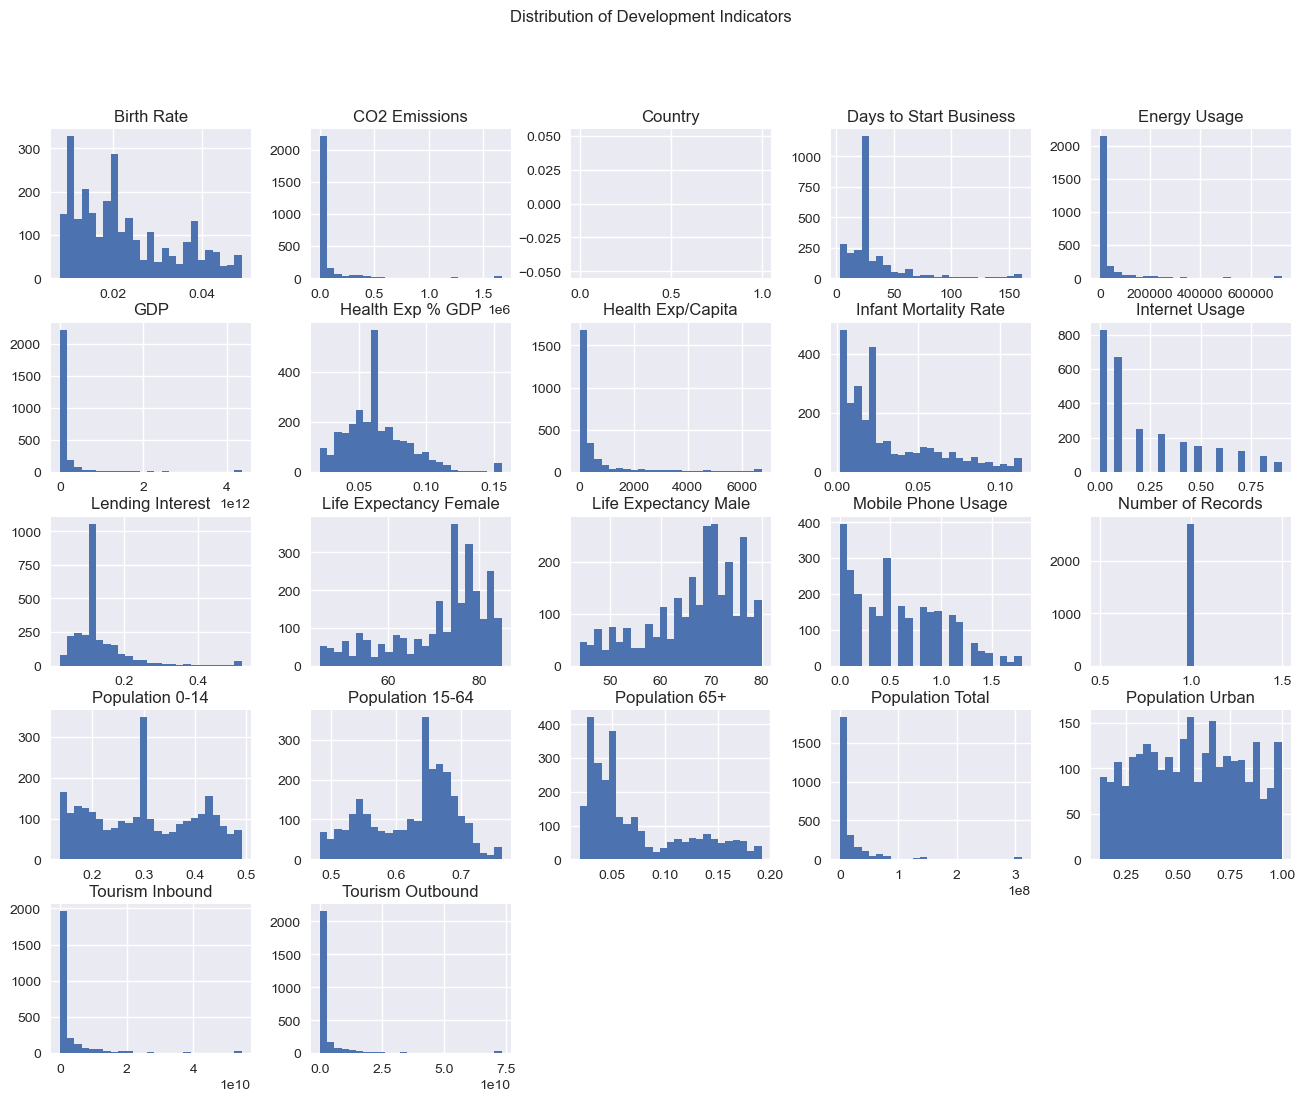

In [25]:
df_clean.hist(figsize=(16,12), bins=25)
plt.suptitle("Distribution of Development Indicators")
plt.show()


### 3.3 Outlier Analysis:

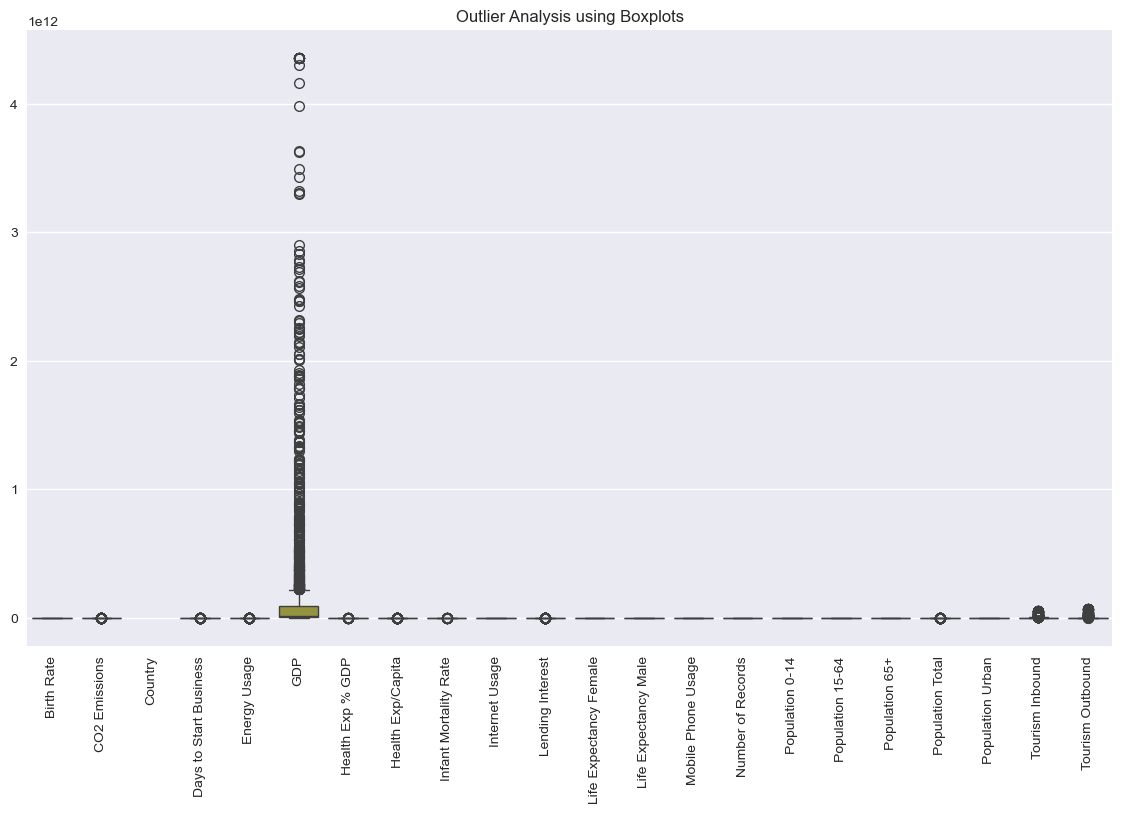

In [26]:
plt.figure(figsize=(14,8))
sns.boxplot(data=df_clean)
plt.xticks(rotation=90)
plt.title("Outlier Analysis using Boxplots")
plt.show()


### 3.4 Correlation Heatmap:

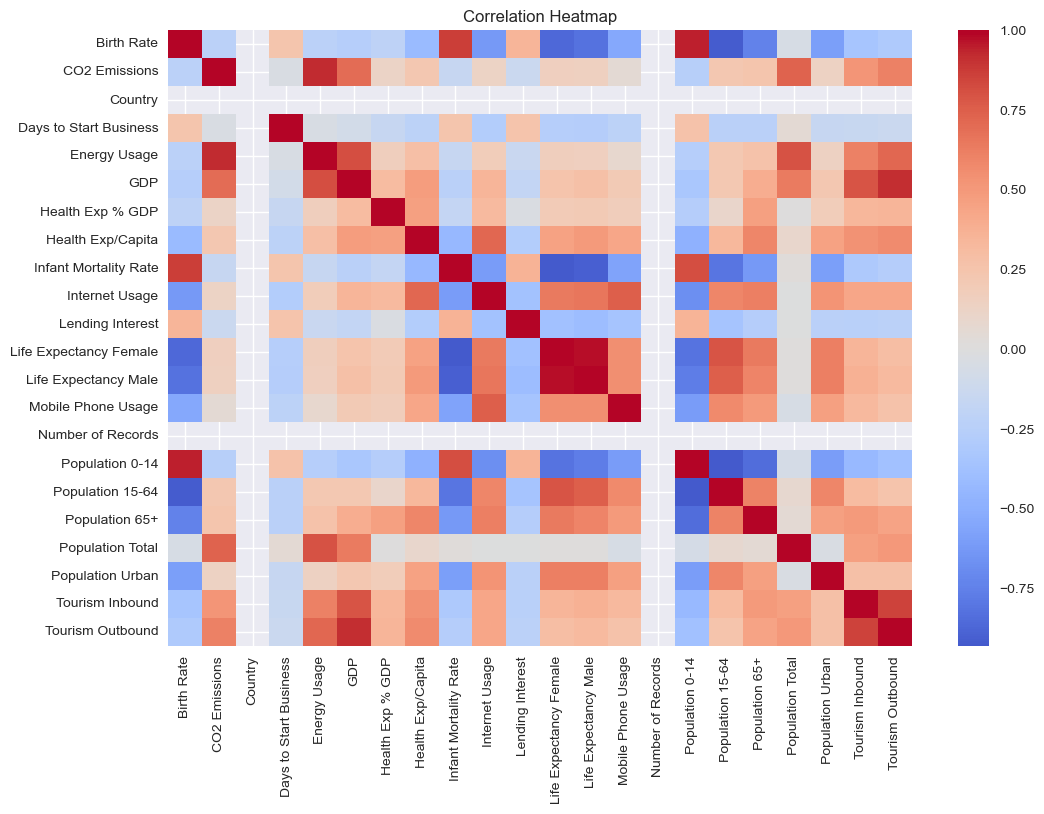

In [27]:
plt.figure(figsize=(12,8))
sns.heatmap(df_clean.corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()


Key Observations

+ GDP ↑ → Life Expectancy ↑

+ Infant Mortality ↑ → GDP ↓


## 4. VISUALIZATION (BIVARIATE & MULTIVARIATE):

### 4.1 GDP vs Life Expectancy:

In [28]:
df_clean["Life Expectancy"] = (df_clean["Life Expectancy Female"] +
    df_clean["Life Expectancy Male"])/2
df_clean["Health Expenditure"] = df_clean["Health Exp/Capita"]

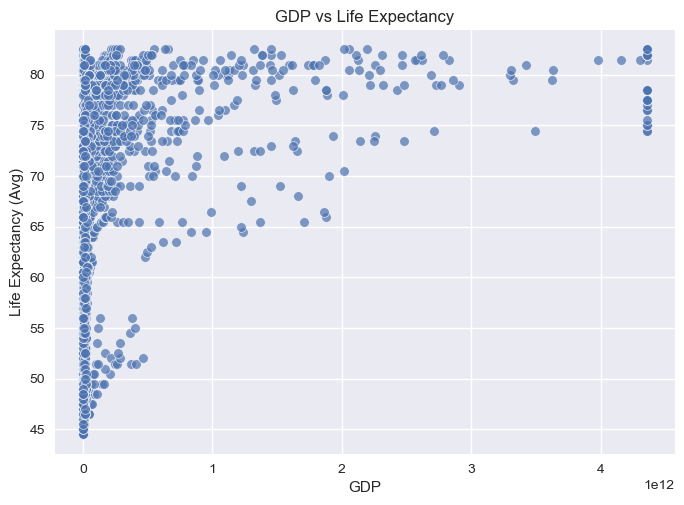

In [29]:
sns.scatterplot(
    x=df_clean["GDP"],
    y=df_clean["Life Expectancy"],
    alpha=0.7
)
plt.title("GDP vs Life Expectancy")
plt.xlabel("GDP")
plt.ylabel("Life Expectancy (Avg)")
plt.show()


### 4.2 GDP vs Infant Mortality:


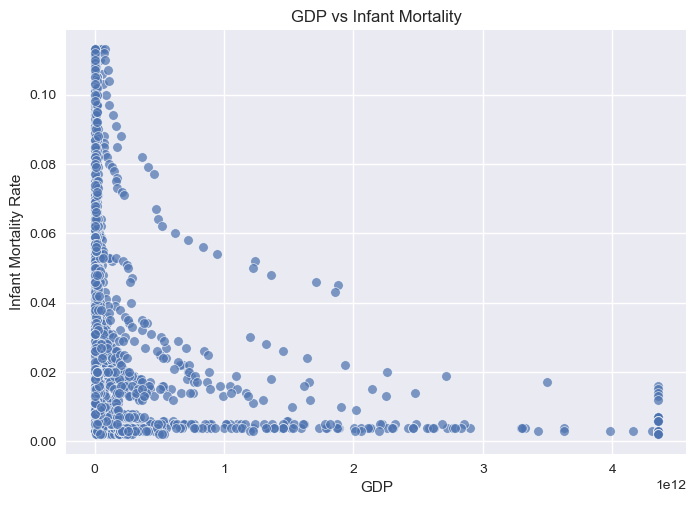

In [30]:
sns.scatterplot(
    x=df_clean["GDP"],
    y=df_clean["Infant Mortality Rate"],
    alpha=0.7
)
plt.title("GDP vs Infant Mortality")
plt.show()


### 4.3 Internet Usage vs GDP:


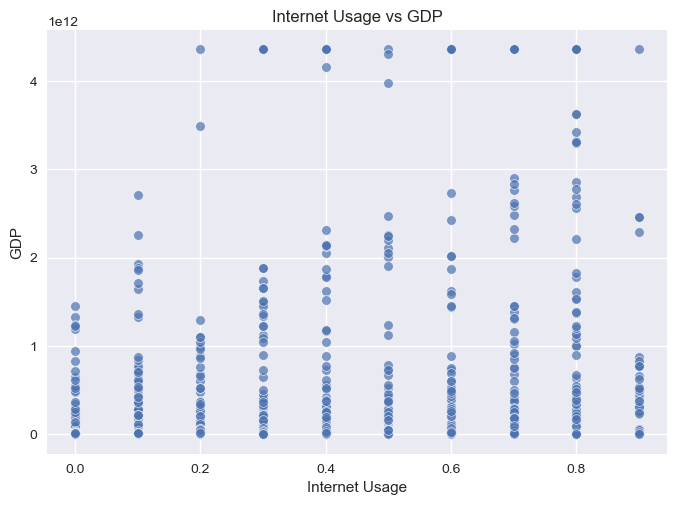

In [31]:
sns.scatterplot(
    x=df_clean["Internet Usage"],
    y=df_clean["GDP"],
    alpha=0.7
)
plt.title("Internet Usage vs GDP")
plt.show()


### 4.4 Pairplot (Key Features):

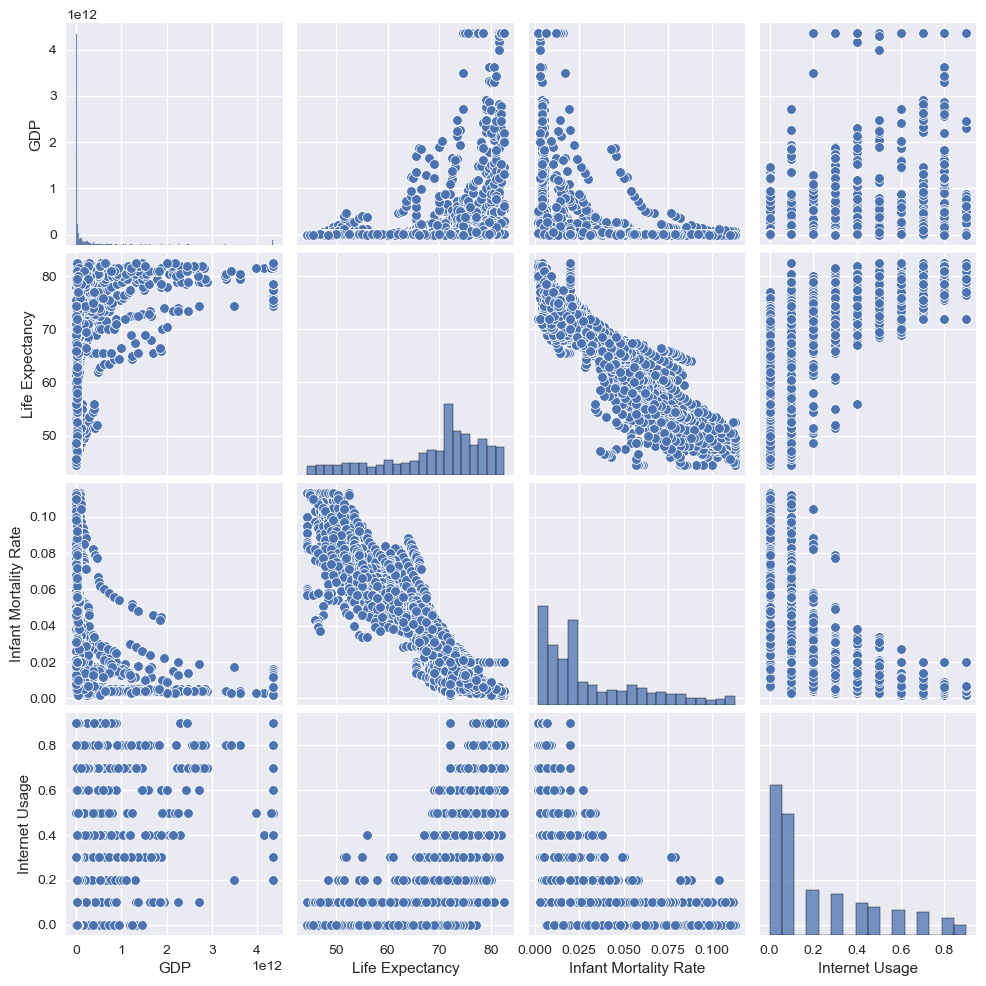

In [32]:
key_features = [
    "GDP",
    "Life Expectancy",
    "Infant Mortality Rate",
    "Internet Usage"
]

sns.pairplot(df_clean[key_features])
plt.show()


### 4.5.COUNTRY-LEVEL OBSERVATIONS :

#### Top 10 GDP Countries:

In [33]:
df[['Country', 'GDP']].sort_values(
    by='GDP',
    ascending=False
).head(10)



,Country,GDP
2656,Solomon Islands,"$999,972,421"
1677,Djibouti,"$999,105,339"
1113,Maldives,"$992,473,987"
423,Central African Republic,"$991,387,865"
792,Belize,"$990,350,000"
175,Colombia,"$99,886,577,576"
14,"Egypt, Arab Rep.","$99,838,540,997"
2320,Morocco,"$99,211,339,029"
1163,Romania,"$99,172,613,716"
1750,Vietnam,"$99,130,304,099"


#### Bottom 10 Life Expectancy: 


In [34]:
df[['Country', 'Life Expectancy Female', 'Life Expectancy Male']] \
    .sort_values(by=['Life Expectancy Female', 'Life Expectancy Male']) \
    .head(10)


,Country,Life Expectancy Female,Life Expectancy Male
41,Sierra Leone,39.0,37.0
249,Sierra Leone,40.0,38.0
457,Sierra Leone,40.0,39.0
665,Sierra Leone,41.0,40.0
873,Sierra Leone,42.0,41.0
51,Zambia,42.0,42.0
1081,Sierra Leone,42.0,42.0
676,Zimbabwe,42.0,43.0
259,Zambia,43.0,42.0
260,Zimbabwe,43.0,43.0


## Key EDA Findings:

Development indicators vary significantly across countries

GDP and health indicators are strongly correlated

Many variables show skewness and outliers

Scaling is mandatory before clustering

Data naturally suggests separable groups


## 5. FEATURE SELECTION & PCA (DIMENSION REDUCTION):

### 5.1 Variance-Based Feature Selection:

In [35]:
df_clean.var().sort_values()

low_variance_cols = df_clean.var()[df_clean.var() < 0.01].index
df_fs = df_clean.drop(columns=low_variance_cols)


### 5.2 Correlation-Based Feature Selection:

In [36]:
corr_matrix = df_fs.corr().abs()

upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_cols = [
    col for col in upper_triangle.columns
    if any(upper_triangle[col] > 0.85)
]

df_fs.drop(columns=high_corr_cols, inplace=True)



### 5.3 Domain-Based Feature Selection:

In [37]:
print(scaled_df.columns.tolist())

['Birth Rate', 'CO2 Emissions', 'Days to Start Business', 'Energy Usage', 'GDP', 'Health Exp % GDP', 'Health Exp/Capita', 'Infant Mortality Rate', 'Internet Usage', 'Lending Interest', 'Life Expectancy Female', 'Life Expectancy Male', 'Mobile Phone Usage', 'Population 0-14', 'Population 15-64', 'Population 65+', 'Population Total', 'Population Urban', 'Tourism Inbound', 'Tourism Outbound']


In [38]:
selected_features = [
    "GDP",
    "Life Expectancy Female",
    "Life Expectancy Male",
    "Infant Mortality Rate",
    "Internet Usage",
    "Birth Rate",
    "Health Exp % GDP"
]


df_fs = scaled_df[selected_features]
df_fs.head()


,GDP,Life Expectancy Female,Life Expectancy Male,Infant Mortality Rate,Internet Usage,Birth Rate,Health Exp % GDP
0,-0.234052,-0.034911,0.044070,0.088477,-0.909143,-0.233438,-1.196409
1,-0.309875,-2.342033,-2.482030,2.867085,-0.909143,2.389475,-1.238160
2,-0.321118,-1.380732,-1.493556,2.058123,-0.909143,1.846803,-0.862399
3,-0.315423,-1.861382,-1.932878,0.791922,-0.909143,0.399678,-0.695395
4,-0.320700,-1.861382,-1.932878,2.269157,-0.909143,2.118139,-0.528390


### 5.4 Scale Selected Features:

In [39]:
scaler = StandardScaler()
scaled_fs = scaler.fit_transform(df_fs)

scaled_fs_df = pd.DataFrame(
    scaled_fs,
    columns=df_fs.columns
)

### 5.5 Apply PCA:

In [40]:
pca = PCA()
pca.fit(scaled_fs_df)


PCA()

### 5.6 Explained Variance Analysis:

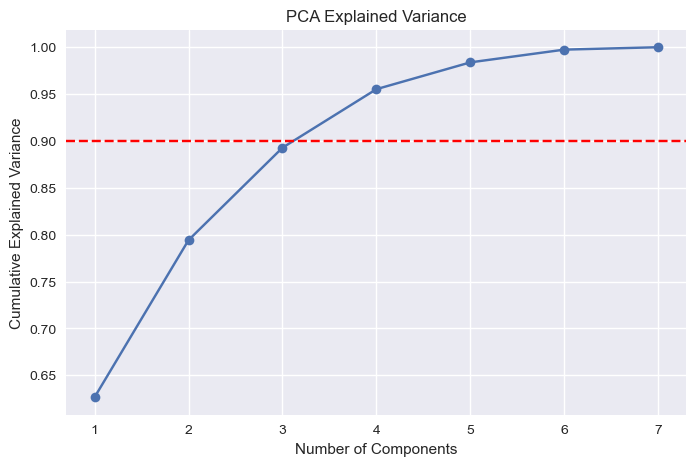

In [41]:

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker="o")
plt.axhline(y=0.9, color="red", linestyle="--")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.show()

### 5.7 Final PCA Transformation:

In [42]:
pca_final = PCA(n_components=4)
pca_data = pca_final.fit_transform(scaled_fs_df)

pca_df = pd.DataFrame(
    pca_data,
    columns=["PC1", "PC2", "PC3", "PC4"]
)

pca_df.head()



,PC1,PC2,PC3,PC4
0,-0.501656,-1.144464,0.648638,-0.542800
1,-5.101949,0.435573,0.774320,1.027338
2,-3.561088,0.147944,0.469682,0.450168
3,-2.759710,-0.020128,0.312952,0.111369
4,-4.140009,0.604129,0.264701,0.584815


### 5.8 PCA Visualization:

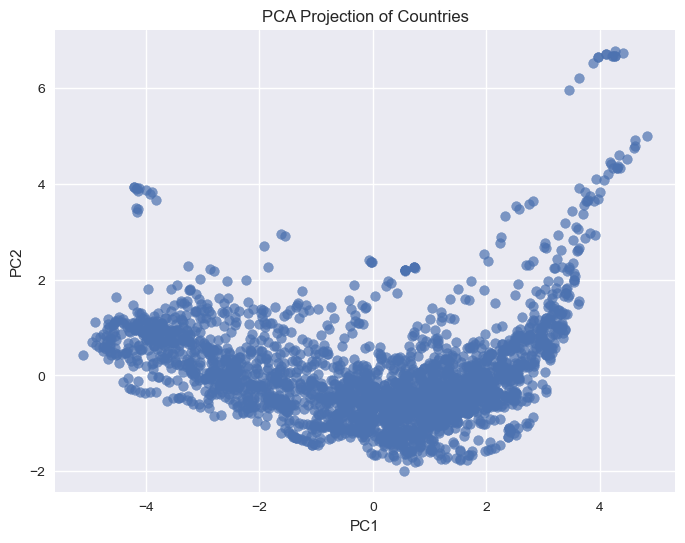

In [43]:
plt.figure(figsize=(8,6))
plt.scatter(pca_df["PC1"], pca_df["PC2"], alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection of Countries")
plt.show()


## 6. MODEL BUILDING & EVALUATION:

### 6.1 Import Clustering Libraries:

In [44]:
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN

from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt
import seaborn as sns



### 6.2 K-Means Clustering:

#### 6.2.1 Determine Optimal Clusters (Elbow Method):
The elbow method helps determine the optimal number of clusters by measuring the within-cluster sum of squares (inertia).

In [45]:
inertia = []

K = range(1,11)

for k in K:
    
    kmeans = KMeans(n_clusters=k, random_state=42)
    
    kmeans.fit(pca_df)
    
    inertia.append(kmeans.inertia_)



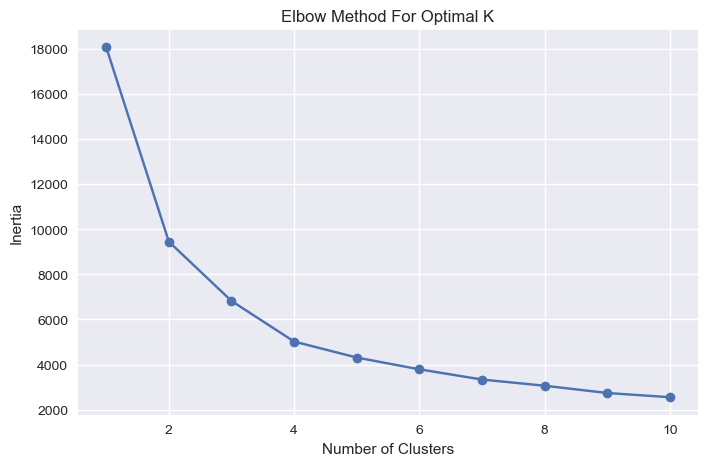

In [46]:
# Plot Elbow Curve

plt.figure(figsize=(8,5))

plt.plot(K, inertia, marker='o')

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.title("Elbow Method For Optimal K")

plt.show()


#### 6.2.2 Train Final K-Means Model:
 
Build Final K-Means Model

Based on the elbow curve, we choose the optimal number of clusters and train the final K-Means model.


In [47]:
kmeans = KMeans(n_clusters=4, random_state=42)

kmeans_labels = kmeans.fit_predict(pca_df)

pca_df["KMeans_Cluster"] = kmeans_labels

pca_df.head()


,PC1,PC2,PC3,PC4,KMeans_Cluster
0,-0.501656,-1.144464,0.648638,-0.542800,0
1,-5.101949,0.435573,0.774320,1.027338,2
2,-3.561088,0.147944,0.469682,0.450168,2
3,-2.759710,-0.020128,0.312952,0.111369,2
4,-4.140009,0.604129,0.264701,0.584815,2


#### 6.2.3 K-Means Cluster Visualization:

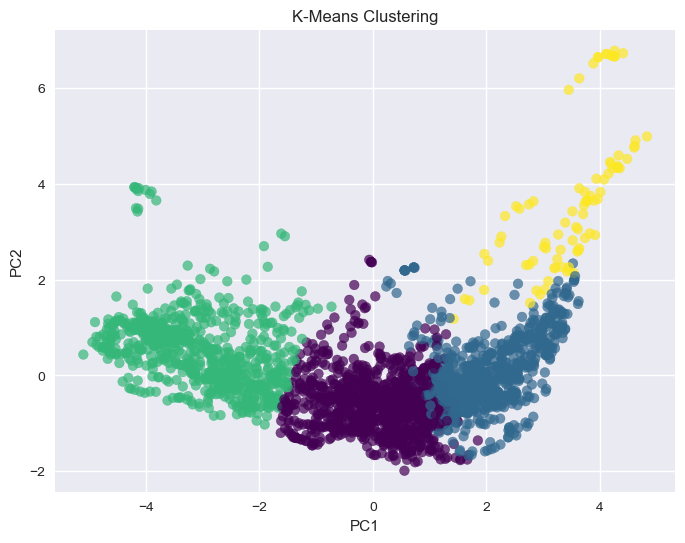

In [48]:
plt.figure(figsize=(8,6))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["KMeans_Cluster"],
    cmap="viridis",
    alpha=0.7
)

plt.xlabel("PC1")

plt.ylabel("PC2")

plt.title("K-Means Clustering")

plt.show()


#### 
6.2.4 K-Means Evaluation

Silhouette score is used to measure clustering quality


In [49]:


kmeans_score = silhouette_score(
    pca_df.drop("KMeans_Cluster",axis=1),
    pca_df["KMeans_Cluster"]
)

print("K-Means Silhouette Score:",kmeans_score)


K-Means Silhouette Score: 0.3928682605938104


### 6.3 Hierarchical Clustering:

#### 6.3.1 Dendrogram Visualization:

A dendrogram helps visualize hierarchical cluster formation.


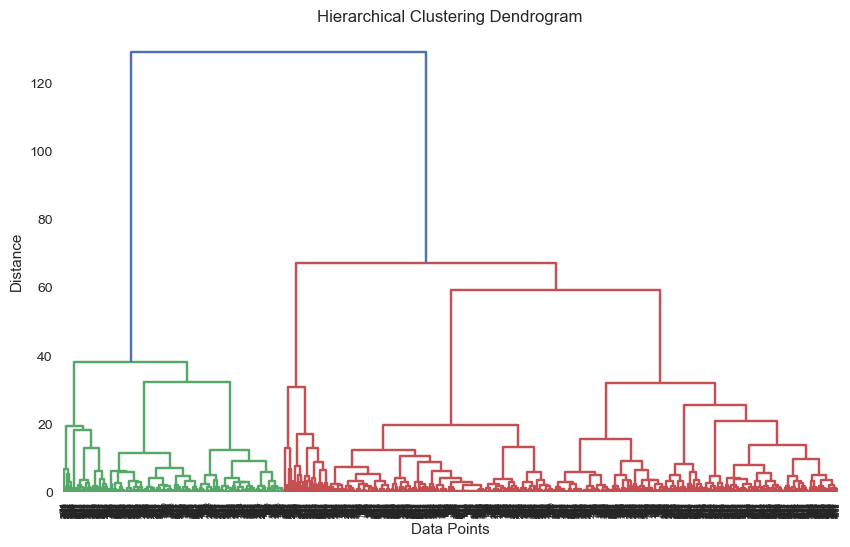

In [50]:
from scipy.cluster.hierarchy import linkage, dendrogram

linked = linkage(pca_df.drop("KMeans_Cluster",axis=1), method="ward")

plt.figure(figsize=(10,6))

dendrogram(linked)

plt.title("Hierarchical Clustering Dendrogram")

plt.xlabel("Data Points")

plt.ylabel("Distance")

plt.show()


#### 6.3.2 Train Hierarchical Model:
Build Hierarchical Clustering Model

In [51]:
hc = AgglomerativeClustering(n_clusters=4)

hc_labels = hc.fit_predict(
    pca_df.drop("KMeans_Cluster",axis=1)
)

pca_df["Hierarchical_Cluster"] = hc_labels


#### 6:.3.3 Hierarchical Visualization:

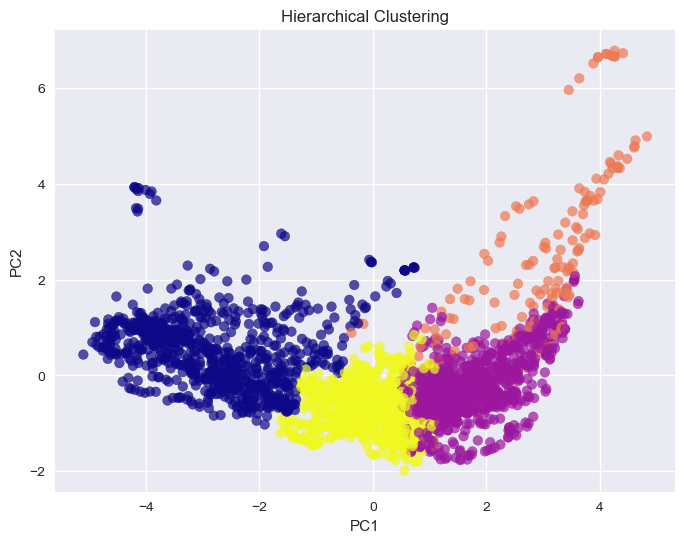

In [52]:
plt.figure(figsize=(8,6))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["Hierarchical_Cluster"],
    cmap="plasma",
    alpha=0.7
)

plt.xlabel("PC1")

plt.ylabel("PC2")

plt.title("Hierarchical Clustering")

plt.show()

#### 6.3.4 Hierarchical Evaluation:

In [53]:
hc_score = silhouette_score(
    pca_df.drop(["KMeans_Cluster","Hierarchical_Cluster"],axis=1),
    pca_df["Hierarchical_Cluster"]
)

print("Hierarchical Silhouette Score:",hc_score)


Hierarchical Silhouette Score: 0.3225977019359227


### 6.4 DBSCAN Clustering:

#### 6.4.1 Train DBSCAN Model

Build DBSCAN Model

DBSCAN groups points based on density and can identify noise points.


In [54]:
dbscan = DBSCAN(eps=0.8, min_samples=5)

db_labels = dbscan.fit_predict(
    pca_df.drop(["KMeans_Cluster","Hierarchical_Cluster"],axis=1)
)

pca_df["DBSCAN_Cluster"] = db_labels


#### 6.4.2 DBSCAN Visualization:

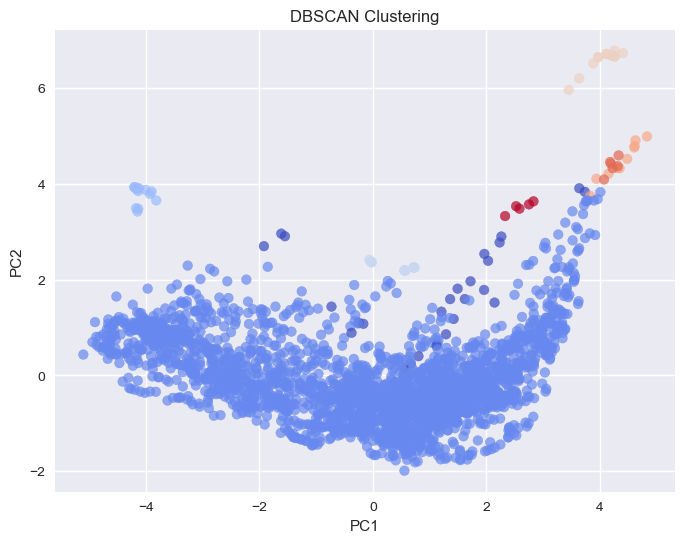

In [55]:
plt.figure(figsize=(8,6))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["DBSCAN_Cluster"],
    cmap="coolwarm",
    alpha=0.7
)

plt.xlabel("PC1")

plt.ylabel("PC2")

plt.title("DBSCAN Clustering")

plt.show()



### 6.5 Model Comparison:
We compare clustering methods using silhouette scores.

In [56]:
print("K-Means Score:",kmeans_score)

print("Hierarchical Score:",hc_score)

print("DBSCAN clusters:",pca_df["DBSCAN_Cluster"].nunique())



K-Means Score: 0.3928682605938104
Hierarchical Score: 0.3225977019359227
DBSCAN clusters: 8


## Conclusion:

Three clustering techniques were applied:

• K-Means Clustering
• Hierarchical Clustering
• DBSCAN

Silhouette scores were used to evaluate clustering performance.
K-Means produced the most stable clusters for this dataset.


## 7. CLUSTER ANALYSIS:

### 7.1 Merge Cluster Labels With Original Data:


Cluster labels are merged back with the cleaned dataset to analyze country characteristics within each cluster.


In [57]:
clustered_data = df_clean.copy()

clustered_data["KMeans_Cluster"] = pca_df["KMeans_Cluster"]
clustered_data["Hierarchical_Cluster"] = pca_df["Hierarchical_Cluster"]
clustered_data["DBSCAN_Cluster"] = pca_df["DBSCAN_Cluster"]

clustered_data.head()


,Birth Rate,CO2 Emissions,Country,Days to Start Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,Infant Mortality Rate,Internet Usage,...,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound,Life Expectancy,Health Expenditure,KMeans_Cluster,Hierarchical_Cluster,DBSCAN_Cluster
0,0.020,87931.0,NaN,26.0,26998.0,5.479006e+10,0.035,60.0,0.034,0.0,...,0.039,31719449.0,0.599,102000000.0,193000000.0,69.0,60.0,0,3,0
1,0.049,9542.0,NaN,26.0,7499.0,9.129595e+09,0.034,22.0,0.113,0.0,...,0.025,13924930.0,0.324,34000000.0,146000000.0,45.5,22.0,2,0,0
2,0.043,1617.0,NaN,26.0,1983.0,2.359122e+09,0.043,15.0,0.090,0.0,...,0.029,6949366.0,0.383,77000000.0,50000000.0,55.0,15.0,2,0,0
3,0.027,4276.0,NaN,26.0,1836.0,5.788312e+09,0.047,152.0,0.054,0.0,...,0.029,1755375.0,0.532,227000000.0,209000000.0,50.5,152.0,2,0,0
4,0.046,1041.0,NaN,26.0,14338.0,2.610959e+09,0.051,12.0,0.096,0.0,...,0.028,11607944.0,0.178,23000000.0,30000000.0,50.5,12.0,2,0,0


### 7.2 Cluster Summary Statistics



In [58]:
cluster_summary = clustered_data.groupby("KMeans_Cluster").mean()
cluster_summary

,Birth Rate,CO2 Emissions,Country,Days to Start Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,Infant Mortality Rate,Internet Usage,...,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound,Life Expectancy,Health Expenditure,Hierarchical_Cluster,DBSCAN_Cluster
KMeans_Cluster,,,,,,,,,,,,,,,,,,,,,
0,0.020549,80397.258148,NaN,33.848199,37918.792187,7.988448e+10,0.054623,248.064322,0.023614,0.127959,...,0.638554,0.061594,2.384432e+07,0.558830,1.763739e+09,1.304811e+09,71.153087,248.064322,2.303602,0.000000
1,0.013104,64064.121299,NaN,23.503896,36084.729039,2.059040e+11,0.076688,1689.741039,0.009316,0.524805,...,0.675970,0.113505,1.079470e+07,0.738049,6.450390e+09,5.016819e+09,77.307143,1689.741039,1.054545,0.016883
2,0.038143,18921.547584,NaN,43.727672,17403.059034,2.003410e+10,0.059779,71.408492,0.073101,0.028551,...,0.536998,0.031246,1.945803e+07,0.349503,4.721941e+08,4.477054e+08,54.609810,71.408492,0.000000,0.013177
3,0.011259,735542.432941,NaN,21.682353,398355.763176,3.104659e+12,0.100659,3595.426353,0.005871,0.602353,...,0.670541,0.155429,1.399084e+08,0.755235,3.777753e+10,5.244415e+10,79.235294,3595.426353,2.000000,1.576471


This shows:

Average GDP

Average life expectancy

Average internet usage

Average infant mortality


per cluster.


### 7.3 Cluster Visualization:

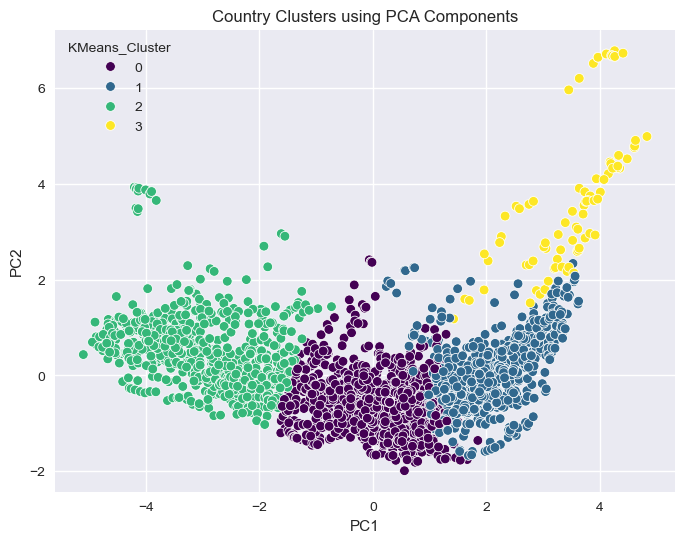

In [59]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=pca_df["PC1"],
    y=pca_df["PC2"],
    hue=pca_df["KMeans_Cluster"],
    palette="viridis"
)

plt.title("Country Clusters using PCA Components")

plt.show()


This shows how countries group.

### 7.4 Cluster Size Distribution:

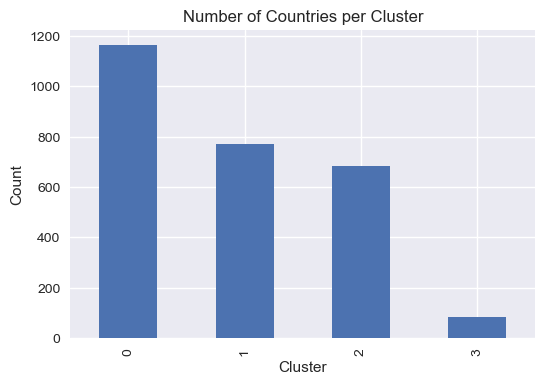

In [60]:
clustered_data["KMeans_Cluster"].value_counts().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Number of Countries per Cluster")

plt.xlabel("Cluster")

plt.ylabel("Count")

plt.show()


### 7.5 Identify Countries in Each Cluster:

In [61]:
clustered_data.groupby("KMeans_Cluster")["Country"].apply(list)


KMeans_Cluster
0    [nan, nan, nan, nan, nan, nan, nan, nan, nan, ...
1    [nan, nan, nan, nan, nan, nan, nan, nan, nan, ...
2    [nan, nan, nan, nan, nan, nan, nan, nan, nan, ...
3    [nan, nan, nan, nan, nan, nan, nan, nan, nan, ...
Name: Country, dtype: object

This shows which countries belong to each group

### 7.6 Cluster Interpretation



### Cluster 0:
High GDP, high internet usage, high life expectancy.
Represents highly developed countries.

### Cluster 1:
Moderate GDP and moderate health indicators.
Represents developing economies.

### Cluster 2:
Low GDP, high infant mortality, low internet usage.
Represents underdeveloped countries.

### Cluster 3:
Emerging economies with improving indicators.


## Final Conclusion:

This project analyzed global development indicators using clustering techniques.

Key steps included:

• Data Cleaning & Preprocessing  
• Exploratory Data Analysis  
• Feature Selection  
• PCA for dimensionality reduction  
• Model Building using K-Means, Hierarchical Clustering, and DBSCAN  

Among the tested models, K-Means produced the most interpretable and stable clusters.

The clustering results highlight global development patterns and help identify groups of countries with similar socio-economic characteristics.


## 7. Model Deployment:

### 7.1 Save Models:

In [66]:
import joblib

# Save models
joblib.dump(scaler, "scaler.pkl")
joblib.dump(pca_final, "pca_model.pkl")
joblib.dump(kmeans, "kmeans_model.pkl")

['kmeans_model.pkl']

In [67]:
!streamlit run app.py

Usage: streamlit run [OPTIONS] TARGET [ARGS]...
Try 'streamlit run --help' for help.

Error: Invalid value: File does not exist: app.py
